In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# used to supress display of warnings
import warnings

# os is used to provide a way of using operating system dependent functionality
# We use it for setting working folder
import os

# Pandas is used for data manipulation and analysis
import pandas as pd 

# Numpy is used for large, multi-dimensional arrays and matrices, along with mathematical operators on these arrays
import numpy as np

# Matplotlib is a data visualization library for 2D plots of arrays, built on NumPy arrays 
# and designed to work with the broader SciPy stack
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import pyplot

# Seaborn is based on matplotlib, which aids in drawing attractive and informative statistical graphics.
import seaborn as sns
import tensorflow 
print(tensorflow.__version__)

2.5.0


In [4]:
os.chdir('/content/drive/MyDrive/Colab Notebooks/R8-Statistical NLP/Assessment')

In [5]:
# suppress display of warnings
warnings.filterwarnings('ignore')

# display all dataframe columns
pd.options.display.max_columns = None

# to set the limit to 3 decimals
pd.options.display.float_format = '{:.7f}'.format

# display all dataframe rows
pd.options.display.max_rows = None

#display max column width
pd.options.display.max_colwidth = None

In [6]:
#NLTK and spacy packages

import nltk
from nltk.corpus import stopwords
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')

#import sentence tokenizer
from nltk import sent_tokenize
#import word tokenizer
from nltk import word_tokenize
import spacy
nlp = spacy.load('en_core_web_sm', parse=True, tag=True, entity=True)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Unzipping corpora/wordnet.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.preprocessing import MultiLabelBinarizer
import re
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import recall_score, precision_score
from sklearn.linear_model import LogisticRegression

In [8]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras import optimizers

In [9]:
#sklearn - libraries
from nltk.tokenize.toktok import ToktokTokenizer
tokenizer = ToktokTokenizer()
stopword_list = nltk.corpus.stopwords.words('english')
stopword_list.remove('no')
stopword_list.remove('not')

**Question:1 - Import and analyse the data set.**

In [10]:
blog_df=pd.read_csv('blogtext.csv')

In [11]:
blog_df.shape

(681284, 7)

In [12]:
blog_df.head(5)

id gender  age              topic      sign          date  \
0  2059027   male   15            Student       Leo   14,May,2004   
1  2059027   male   15            Student       Leo   13,May,2004   
2  2059027   male   15            Student       Leo   12,May,2004   
3  2059027   male   15            Student       Leo   12,May,2004   
4  3581210   male   33  InvestmentBanking  Aquarius  11,June,2004   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

**Question #2: Perform data pre-processing on the data:**

• Data cleansing by removing unwanted characters, spaces, stop words etc. Convert text to lowercase.

• Target/label merger and transformation

• Train and test split

• Vectorisation, etc. 


In [13]:
blog_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 681284 entries, 0 to 681283
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      681284 non-null  int64 
 1   gender  681284 non-null  object
 2   age     681284 non-null  int64 
 3   topic   681284 non-null  object
 4   sign    681284 non-null  object
 5   date    681284 non-null  object
 6   text    681284 non-null  object
dtypes: int64(2), object(5)
memory usage: 36.4+ MB


In [14]:
blog_df.describe(include = [np.object]).T

,count,unique,top,freq
gender,681284,2,male,345193
topic,681284,40,indUnk,251015
sign,681284,12,Cancer,65048
date,681284,2616,"02,August,2004",16544
text,681284,611652,urlLink,445


**2.a - Data cleansing by removing unwanted characters, spaces, stop words etc. Convert text to lowercase**

In [15]:
blog_df['text']=blog_df['text'].astype('str')
blog_df['age']=blog_df['age'].astype('str')

In [16]:
blog_df['lemma'] = blog_df['text']
blog_df['lemma'] = blog_df['lemma'].apply(lambda x: x.lower())
blog_df['lemma'] = blog_df['lemma'].str.replace('[^\w\s]','')
blog_df['lemma'] = blog_df['lemma'].str.strip()
blog_df['lemma'] = blog_df['lemma'].apply(lambda x: ' '.join(x for x in x.split() if not x.isdigit()))
blog_df['lemma'] = blog_df['lemma'].apply(lambda x: ' '.join([word for word in x.split() if word not in stopword_list]))

In [17]:
import string
PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('','',PUNCT_TO_REMOVE))
                                        
blog_df['lemma'] = blog_df['lemma'].apply(lambda text: remove_punctuation(text))
blog_df['lemma'].head()

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [19]:
w_tokenizer=nltk.tokenize.WhitespaceTokenizer()
lemmatizer=nltk.stem.WordNetLemmatizer()

def lemmatize_text(text):
  return " ".join(lemmatizer.lemmatize(w) for w in w_tokenizer.tokenize(text))

In [20]:
blog_df['lemma'] = blog_df['lemma'].apply(lambda x: lemmatize_text(x))

**2.b - Target/label merger and transformation**

In [21]:
df_labels=blog_df[:100000]
df_labels['age'] = df_labels['age'].astype(str)
#df_labels['labels']=df_labels[['gender','age','topic','sign']].apply(lambda x: ','.join(x), axis = 1) 
df_labels['labels'] = df_labels.apply(lambda x : [x["gender"],x["age"],x["topic"],x["sign"]], axis =1)
df_labels=df_labels.drop(['text','date','gender', 'age','topic','sign','id'], axis = 1)

In [22]:
X=df_labels['lemma']
y=df_labels['labels']

In [23]:
df_labels.head(2)

,lemma,labels
0,info found page mb pdf file wait untill team leader processed learns html,"[male, 15, Student, Leo]"
1,team member drewes van der laag urllink mail ruiyu xie urllink mail bryan aaldering urllink mail,"[male, 15, Student, Leo]"


In [22]:
#df_labels['labels'].value_counts()

In [24]:
orignal_mem = df_labels.memory_usage(deep=True)
orignal_mem

Index          128
lemma     71803805
labels     8000000
dtype: int64

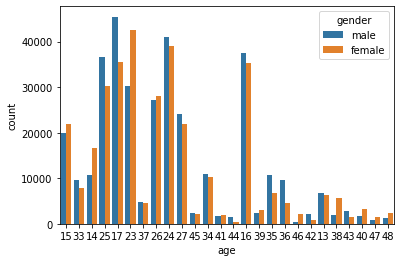

In [98]:
sns.countplot(x="age", hue="gender", data=blog_df)

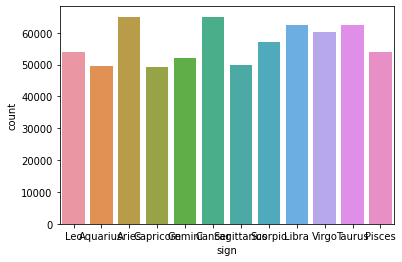

In [92]:
sns.countplot(x='sign',data=blog_df)

Notes:

Vectorize then split

If we vectorize then we train/test split, our document-term matrix would contain every single feature (word) in the test and training sets
What we want is to simulate the real world
We would always see words we have not seen before so this method is not realistic and we cannot properly evaluate our models

Split then vectorize (correct way)

We do the train/test split before the CountVectorizer to properly simulate the real world where our future data contains words we have not seen before
After you train your data and chose the best model, you would then train on all of your data before predicting actual future data to maximize learning.

**2.c - Train and test split**

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30,random_state=43)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(70000,)
(30000,)
(70000,)
(30000,)


**2.d - Vectorisation, etc.**

1. Count Vectorization
2. Tfidf Vectorization 

In [26]:
ctvectorizer = CountVectorizer(analyzer='word', token_pattern=r'\w{1,}', min_df = 2,ngram_range = (1,2),stop_words = "english", max_df=3)
corpus = list(X_train)+list(X_test)
ctvectorizer.fit(corpus)

CountVectorizer(analyzer='word', binary=False, decode_error='strict',
                dtype=<class 'numpy.int64'>, encoding='utf-8', input='content',
                lowercase=True, max_df=3, max_features=None, min_df=2,
                ngram_range=(1, 2), preprocessor=None, stop_words='english',
                strip_accents=None, token_pattern='\\w{1,}', tokenizer=None,
                vocabulary=None)

In [27]:
xtrain_ctv = ctvectorizer.transform(X_train)
xtest_ctv = ctvectorizer.transform(X_test)

In [28]:
print(len(ctvectorizer.vocabulary_))

656325


In [29]:
ctvectorizer.get_feature_names()[:10]

['00 quite',
 '000000this',
 '000000this certifies',
 '0020hrs',
 '03nbsp',
 '03nbsp urllink',
 '04ck05',
 '04s7a',
 '0630nbsp',
 '0645hrs']

In [30]:
tfidfvectorizer = TfidfVectorizer(analyzer='word', token_pattern=r'\w{1,}', min_df = 2,ngram_range = (1,2),stop_words = "english", max_df=3)
corpus = list(X_train)+list(X_test)
tfidfvectorizer.fit(corpus)

TfidfVectorizer(analyzer='word', binary=False, decode_error='strict',
                dtype=<class 'numpy.float64'>, encoding='utf-8',
                input='content', lowercase=True, max_df=3, max_features=None,
                min_df=2, ngram_range=(1, 2), norm='l2', preprocessor=None,
                smooth_idf=True, stop_words='english', strip_accents=None,
                sublinear_tf=False, token_pattern='\\w{1,}', tokenizer=None,
                use_idf=True, vocabulary=None)

In [31]:
xtrain_idfvect = tfidfvectorizer.fit_transform(X_train)
xtest_idfvect = tfidfvectorizer.transform(X_test)

In [32]:
print(len(tfidfvectorizer.vocabulary_))

466042


In [33]:
df_labels.labels.values

array([list(['male', '15', 'Student', 'Leo']),
       list(['male', '15', 'Student', 'Leo']),
       list(['male', '15', 'Student', 'Leo']), ...,
       list(['male', '27', 'Student', 'Virgo']),
       list(['male', '27', 'Student', 'Virgo']),
       list(['male', '27', 'Student', 'Virgo'])], dtype=object)

In [34]:
label_counts=dict()

for labels in df_labels.labels.values:
    for label in labels:
        if label in label_counts:
            label_counts[str(label)]+=1
        else:
            label_counts[str(label)]=1
        
#label_counts

In [ ]:
sorted(label_counts.keys())

**Question 3. Design, train, tune and test the best text classifier.**

Step 1: Transform the labels into binaries using Multi Label Binarizer.

Step 2: create, build and run the Logistic algorithm using Bag of words created using count vectorizer.

Step 3: create, build and run the MultiNomial Naive Bayes algorithm using words created by TfIdf vectorizer.

In [35]:
# Transform between iterable of iterables and a multilabel format
mlb=MultiLabelBinarizer(classes=sorted(label_counts.keys()))

y_train = mlb.fit_transform(y_train)
y_test = mlb.transform(y_test)

In [36]:
y_train, y_test

(array([[0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 1, 1],
        [0, 0, 1, ..., 1, 0, 0],
        ...,
        [0, 0, 0, ..., 1, 0, 0],
        [0, 1, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 1, 1, 0]]), array([[0, 0, 0, ..., 0, 1, 1],
        [0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 1, 0, 0],
        ...,
        [0, 0, 0, ..., 1, 1, 0],
        [0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 0, 1]]))

In [37]:
def display_metrics_micro(Ytest, Ypred):
    print('Testing Accuracy score: ', accuracy_score(Ytest, Ypred))
    print('F1 score: Micro', f1_score(Ytest, Ypred, average='micro'))
    print('Average precision score: Micro', average_precision_score(Ytest, Ypred, average='micro'))
    print('Average recall score: Micro', recall_score(Ytest, Ypred, average='micro'))
    
    
def display_metrics_macro(Ytest, Ypred):
    print('Accuracy score: ', accuracy_score(Ytest, Ypred))
    print('F1 score: Macro', f1_score(Ytest, Ypred, average='macro'))
    print('Average recall score: Macro', recall_score(Ytest, Ypred, average='macro'))
    
def display_metrics_weighted(Ytest, Ypred):
    print('Accuracy score: ', accuracy_score(Ytest, Ypred))
    print('F1 score: weighted', f1_score(Ytest, Ypred, average='weighted'))
    print('Average precision score: weighted', average_precision_score(Ytest, Ypred, average='weighted'))
    print('Average recall score: weighted', recall_score(Ytest, Ypred, average='weighted'))

In [39]:
# Using pipeline for applying logistic regression and one vs rest classifier
LogReg_pipeline = Pipeline([
                ('clf', OneVsRestClassifier(LogisticRegression(solver='lbfgs', penalty='l2', multi_class='auto', max_iter=1000 ),
                    n_jobs=None)),])
LogReg_pipeline.fit(xtrain_ctv, y_train)

Y_predicted_logreg = LogReg_pipeline.predict(xtest_ctv)

In [40]:
display_metrics_micro(y_test,Y_predicted_logreg)

Testing Accuracy score:  0.011033333333333332
F1 score: Micro 0.281741571208587
Average precision score: Micro 0.15649444992921815
Average recall score: Micro 0.180675


In [41]:
display_metrics_macro(y_test,Y_predicted_logreg)

Accuracy score:  0.011033333333333332
F1 score: Macro 0.04350648242239863
Average recall score: Macro 0.03060816340941259


In [42]:
display_metrics_weighted(y_test,Y_predicted_logreg)

Accuracy score:  0.011033333333333332
F1 score: weighted 0.19345519241609846
Average precision score: weighted 0.2418753406471155
Average recall score: weighted 0.180675


In [43]:
import random 

def print_predicted(y_predicted, y_test = y_test , n = 5):
    j = []
    for i in range(n):
        j.append(random.randint(0, len(y_test)))
    print(j)
                 
    for k in j:
        print(mlb.inverse_transform(y_predicted)[k])
        print(mlb.inverse_transform(y_test)[k])
        print("=================x==================x================x==========")

In [44]:
print_predicted(y_predicted=Y_predicted_logreg,y_test=y_test, n= 10)

[5205, 17499, 11565, 24335, 15810, 19869, 7504, 24073, 29020, 5129]
('male',)
('23', 'Pisces', 'indUnk', 'male')
=================x==================x================x==========
('female',)
('23', 'Internet', 'Leo', 'male')
=================x==================x================x==========
('female',)
('17', 'Gemini', 'indUnk', 'male')
=================x==================x================x==========
('male',)
('24', 'Aries', 'indUnk', 'male')
=================x==================x================x==========
('male',)
('23', 'Sagittarius', 'indUnk', 'male')
=================x==================x================x==========
('male',)
('23', 'Capricorn', 'Technology', 'female')
=================x==================x================x==========
('male',)
('33', 'Cancer', 'Internet', 'male')
=================x==================x================x==========
('male',)
('23', 'Banking', 'Capricorn', 'male')
=================x==================x================x==========
('male',)
('24', 'Aquarius', '

In [45]:
# Using pipeline for applying logistic regression and one vs rest classifier
MNB_pipeline = Pipeline([
                ('clf', OneVsRestClassifier(MultinomialNB(
                    alpha=0.01, fit_prior=True, class_prior=None),
                    n_jobs=-1)),])
MNB_pipeline.fit(xtrain_idfvect, y_train)

Y_predicted_MNB = MNB_pipeline.predict(xtest_idfvect)

In [46]:
display_metrics_micro(y_test,Y_predicted_MNB)

Testing Accuracy score:  0.06653333333333333
F1 score: Micro 0.36356190562861174
Average precision score: Micro 0.18918464717404807
Average recall score: Micro 0.2663333333333333


In [47]:
display_metrics_macro(y_test,Y_predicted_MNB)

Accuracy score:  0.06653333333333333
F1 score: Macro 0.16282201226629303
Average recall score: Macro 0.10649914411275323


In [48]:
display_metrics_weighted(y_test,Y_predicted_MNB)

Accuracy score:  0.06653333333333333
F1 score: weighted 0.31818672240229157
Average precision score: weighted 0.27015511705508766
Average recall score: weighted 0.2663333333333333


In [49]:
print_predicted(y_predicted=Y_predicted_MNB,y_test=y_test, n= 10)

[4483, 16037, 16637, 4139, 19416, 29987, 1150, 4265, 12291, 13258]
('male',)
('27', 'Religion', 'Taurus', 'female')
=================x==================x================x==========
('female', 'indUnk')
('34', 'Pisces', 'female', 'indUnk')
=================x==================x================x==========
('33', 'Pisces', 'indUnk', 'male')
('33', 'Pisces', 'indUnk', 'male')
=================x==================x================x==========
('male',)
('35', 'Aries', 'Technology', 'male')
=================x==================x================x==========
('male',)
('23', 'Arts', 'Leo', 'female')
=================x==================x================x==========
('male',)
('25', 'Arts', 'Virgo', 'male')
=================x==================x================x==========
('15', 'male')
('15', 'Leo', 'Student', 'male')
=================x==================x================x==========
('male',)
('26', 'Aquarius', 'Arts', 'male')
=================x==================x================x==========
('26', 'mal

**Question 4. Display and explain detail the classification report**

In [89]:
print("Classifcation Report - Multinomial NB")
print(classification_report(y_test,Y_predicted_MNB))

Classifcation Report - Multinomial NB
              precision    recall  f1-score   support

           0       0.80      0.18      0.29       424
           1       0.64      0.15      0.24      1125
           2       0.53      0.14      0.22      1936
           3       0.64      0.22      0.33      2494
           4       0.46      0.14      0.22      3806
           5       0.43      0.10      0.16      3339
           6       0.45      0.13      0.20      3498
           7       0.39      0.09      0.14      2679
           8       0.44      0.10      0.16      2370
           9       0.44      0.10      0.17      2391
          10       0.39      0.06      0.11       833
          11       0.79      0.26      0.39       714
          12       0.62      0.11      0.18      1398
          13       0.59      0.13      0.21       919
          14       0.78      0.07      0.13       258
          15       0.54      0.06      0.10       241
          16       0.71      0.09      0.16

In [90]:
print("Classifcation Report - logistic regression")
print(classification_report(y_test,Y_predicted_logreg))

Classifcation Report - logistic regression
              precision    recall  f1-score   support

           0       1.00      0.02      0.04       424
           1       0.86      0.02      0.04      1125
           2       0.86      0.02      0.03      1936
           3       0.95      0.12      0.21      2494
           4       0.80      0.02      0.04      3806
           5       0.76      0.02      0.05      3339
           6       0.71      0.01      0.02      3498
           7       0.62      0.01      0.03      2679
           8       0.56      0.01      0.03      2370
           9       0.86      0.01      0.03      2391
          10       0.35      0.01      0.02       833
          11       0.94      0.02      0.05       714
          12       0.89      0.01      0.02      1398
          13       0.86      0.01      0.01       919
          14       0.75      0.01      0.02       258
          15       1.00      0.00      0.01       241
          16       0.00      0.00     

**Observation**

I have used
  1. count vectorization + logistic regression,
  2. TfIdf vectorization + multinomialNB

From above classification, it is understood that multinomialNB algorithm predicts the classes better than logistic regression.

The logistic algorithm is built on 656325 words and multinomial NB alg built on 466042 bag of words.

The recall value (using multinomial NB alg)is relatively high - meaning the model has predicted the classes correctly using Tfidf + multinomial NB algorithm.

**Question 5. Print the true vs predicted labels for any 5 entries from the dataset.**

In [74]:
y_test[:1]

array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]])

In [75]:
Y_predicted_MNB[:1]

array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1]])

In [52]:
preds=Y_predicted_MNB[:15]
print(preds)

actuals=y_test[:15]
print(actuals)

[[0 0 0 ... 0 1 1]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 1 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 1]]
[[0 0 0 ... 0 1 1]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 1 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 1 ... 0 0 1]
 [0 0 0 ... 1 0 0]]


In [53]:
five_actual = mlb.inverse_transform(actuals)
five_actual

[('23', 'Aquarius', 'indUnk', 'male'),
 ('35', 'Aries', 'Technology', 'male'),
 ('23', 'Education', 'Leo', 'female'),
 ('17', 'Capricorn', 'Student', 'female'),
 ('15', 'Cancer', 'Student', 'female'),
 ('25', 'Aquarius', 'Arts', 'female'),
 ('15', 'Cancer', 'Student', 'female'),
 ('15', 'Aries', 'indUnk', 'male'),
 ('27', 'Gemini', 'Religion', 'female'),
 ('17', 'Capricorn', 'Student', 'female'),
 ('15', 'Gemini', 'female', 'indUnk'),
 ('17', 'Aquarius', 'female', 'indUnk'),
 ('23', 'Cancer', 'Engineering', 'female'),
 ('15', 'Leo', 'Student', 'male'),
 ('26', 'Advertising', 'Cancer', 'female')]

In [54]:
five_pred = mlb.inverse_transform(preds)
five_pred

[('23', 'Aquarius', 'indUnk', 'male'),
 ('male',),
 ('female',),
 ('male',),
 ('15', 'Cancer', 'Student', 'female'),
 ('Student', 'male'),
 ('Student', 'female'),
 ('indUnk', 'male'),
 ('male',),
 ('Student', 'female'),
 ('17', 'female'),
 ('Libra', 'female'),
 ('23', 'Cancer', 'female'),
 ('male',),
 ('27', 'Cancer', 'male')]

**Print true label and predicted label for any five examples**

In [81]:
print(mlb.inverse_transform(Y_predicted_logreg)[877])
print(mlb.inverse_transform(y_test)[877])

('male',)
('43', 'Taurus', 'female', 'indUnk')


In [80]:
#print(mlb.inverse_transform(Y_predicted_MNB)[514])
print(mlb.inverse_transform(Y_predicted_logreg)[514])
print(mlb.inverse_transform(y_test)[514])

('male',)
('17', 'Capricorn', 'Student', 'male')


In [82]:
#print(mlb.inverse_transform(Y_predicted_MNB)[1024])
print(mlb.inverse_transform(Y_predicted_logreg)[1024])
print(mlb.inverse_transform(y_test)[1024])

('male',)
('34', 'Aquarius', 'Education', 'male')


In [83]:
#print(mlb.inverse_transform(Y_predicted_MNB)[2400])
print(mlb.inverse_transform(Y_predicted_logreg)[2400])
print(mlb.inverse_transform(y_test)[2400])

('male',)
('24', 'Leo', 'Student', 'male')


In [84]:
#print(mlb.inverse_transform(Y_predicted_MNB)[5000])
print(mlb.inverse_transform(Y_predicted_logreg)[5000])
print(mlb.inverse_transform(y_test)[5000])

('male',)
('26', 'Student', 'Taurus', 'male')


In [85]:
import random
j=[]
for i in range(5):
    j.append(random.randint(300,len(Y_predicted_MNB)))
   
print(j)

for k in j:    
    print(mlb.inverse_transform(Y_predicted_MNB)[k])
    print(mlb.inverse_transform(y_test)[k])
    

[26021, 8460, 1579, 26359, 20947]
('male',)
('14', 'Biotech', 'Pisces', 'male')
('male',)
('24', 'Taurus', 'Technology', 'male')
('female',)
('23', 'Capricorn', 'Engineering', 'male')
('16', 'Leo', 'Student', 'female')
('15', 'Gemini', 'Student', 'male')
('male',)
('27', 'Gemini', 'Religion', 'female')


In [63]:
Ypred_inversed = mlb.inverse_transform(Y_predicted_MNB)
y_test_inversed = mlb.inverse_transform(y_test)
for i in range(5):
    print('Text:\t{}\nTrue labels:\t{}\nPredicted labels:\t{}\n\n'.format(
        xtest_idfvect[i],
        ','.join(y_test_inversed[i]),
        ','.join(Ypred_inversed[i])
    ))

Text:	  (0, 136680)	0.6977267113903083
  (0, 31723)	0.7163640388883752
True labels:	23,Aquarius,indUnk,male
Predicted labels:	23,Aquarius,indUnk,male


Text:	  (0, 444193)	0.5874950404839708
  (0, 309323)	0.5722104409248129
  (0, 24767)	0.5722104409248129
True labels:	35,Aries,Technology,male
Predicted labels:	male


Text:	  (0, 426301)	0.305093384941748
  (0, 320691)	0.305093384941748
  (0, 278871)	0.29715590480039883
  (0, 266897)	0.305093384941748
  (0, 266315)	0.305093384941748
  (0, 258972)	0.305093384941748
  (0, 248534)	0.29715590480039883
  (0, 111992)	0.29715590480039883
  (0, 107505)	0.29715590480039883
  (0, 63921)	0.29715590480039883
  (0, 27181)	0.305093384941748
True labels:	23,Education,Leo,female
Predicted labels:	female


Text:	
True labels:	17,Capricorn,Student,female
Predicted labels:	male


Text:	  (0, 349065)	0.7071067811865476
  (0, 214064)	0.7071067811865476
True labels:	15,Cancer,Student,female
Predicted labels:	15,Cancer,Student,female




**Additionally, try using multiple algorithm and understand how the text classification is done.**

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

def build_model_train(X_train, y_train, X_valid=None, y_valid=None, C=1.0, model='lr'):
    if model=='lr':
        model = LogisticRegression(C=C, penalty='l1', dual=False, solver='liblinear')
        model = OneVsRestClassifier(model)
        model.fit(xtrain_idfvect, y_train)
    
    elif model=='svm':
        model = LinearSVC(C=C, penalty='l1', dual=False, loss='squared_hinge')
        model = OneVsRestClassifier(model)
        model.fit(xtrain_idfvect, y_train)
    
    elif model=='nbayes':
        model = MultinomialNB(alpha=1.0)
        model = OneVsRestClassifier(model)
        model.fit(xtrain_idfvect, y_train)
        
    elif model=='lda':
        model = LinearDiscriminantAnalysis(solver='svd')
        model = OneVsRestClassifier(model)
        model.fit(xtrain_idfvect, y_train)

    return model

In [72]:
models = ['lr','svm','nbayes']
for model in models:
    model = build_model_train(xtrain_idfvect,y_train,model=model)
    model.fit(xtrain_idfvect,y_train)
    Ypred=model.predict(xtest_idfvect)
    print("\n")
    print(f"**displaying  metrics for the mode {model}\n")
    display_metrics_micro(y_test,Ypred)
    print("\n")
    print("\n")
    display_metrics_macro(y_test,Ypred)
    print("\n")
    print("\n")
    display_metrics_weighted(y_test,Ypred)
    print("\n")
    print("\n")
    



**displaying  metrics for the mode OneVsRestClassifier(estimator=LogisticRegression(C=1.0, class_weight=None,
                                                 dual=False, fit_intercept=True,
                                                 intercept_scaling=1,
                                                 l1_ratio=None, max_iter=100,
                                                 multi_class='auto',
                                                 n_jobs=None, penalty='l1',
                                                 random_state=None,
                                                 solver='liblinear', tol=0.0001,
                                                 verbose=0, warm_start=False),
                    n_jobs=None)

Testing Accuracy score:  0.0011333333333333334
F1 score: Micro 0.21797722884346493
Average precision score: Micro 0.11714010033675609
Average recall score: Micro 0.13640833333333333




Accuracy score:  0.0011333333333333334
F1 score: Macro 0.016147746